In [8]:
# Instalação e importações de bibliotecas

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

df = pd.read_excel('https://drive.google.com/uc?export=download&id=1LGQWS6zN8yc7coP-HrWm5MygUUyp1afX')

display(df.head(10))

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,ARM,Armenia,Asia,Western Asia,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,35.0,CTS
1,CHE,Switzerland,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,28.0,CTS
2,COL,Colombia,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,15053.0,CTS
3,CZE,Czechia,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,69.0,CTS
4,DEU,Germany,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,455.0,CTS
5,FIN,Finland,Europe,Northern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,70.0,CTS
6,GTM,Guatemala,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,2764.0,CTS
7,HND,Honduras,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,905.0,CTS
8,HUN,Hungary,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,229.0,CTS
9,ISL,Iceland,Europe,Northern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,1.0,CTS


In [9]:
# Limpeza e Filtragem dos Dados


df_filtrado = df[(df['Year'] >= 2013) & (df['Year'] <= 2022)].copy()
df_homicidios = df_filtrado[df_filtrado['Indicator'] == 'Victims of intentional homicide'].copy()

# Colunas a serem utilizadas
colunas_uteis = ['Country', 'Region', 'Subregion', 'Indicator', 'Sex', 'Year', 'VALUE']
df_clean = df_homicidios[colunas_uteis]


display(df_clean.head())

,Country,Region,Subregion,Indicator,Sex,Year,VALUE
4218,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,6.0
4219,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,1.0
4220,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,2013,124.0
4221,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,2013,0.0
4222,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,2013,57.0


--- TOP 10 PAÍSES COM MAIORES TAXAS DE HOMICÍDIOS POR 100 MIL HAB. (MÉDIA 2018-2022) ---


,Country,VALUE
0,Iraq (Central Iraq),39.910609
1,South Africa,35.779754
2,Venezuela (Bolivarian Republic of),22.468721
3,Nigeria,21.740789
4,American Samoa,13.423096
5,Brazil,13.292863
6,French Guiana,13.200023
7,Jamaica,12.795411
8,Puerto Rico,12.567775
9,Haiti,12.274497


C:\Users\User\AppData\Local\Temp\ipykernel_11556\2092240815.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_paises, x='VALUE', y='Country', palette='Reds_r')


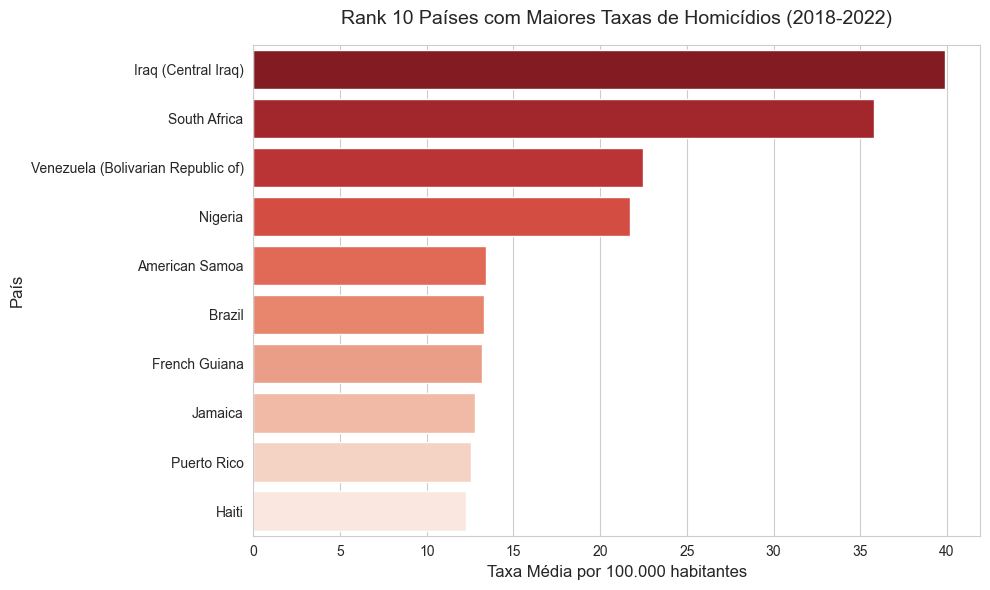

In [10]:
# 10 países com maiores taxas de homicídios (2018-2022)

# Pergunta 1 - Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?

#Filtramos somente o que vamosm usar nessa questão
df_p1 = df[
    (df['Year'] >= 2018) &
    (df['Year'] <= 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

top_10_paises = df_p1.groupby('Country')['VALUE'].mean().sort_values(ascending=False).head(10).reset_index()

print("--- TOP 10 PAÍSES COM MAIORES TAXAS DE HOMICÍDIOS POR 100 MIL HAB. (MÉDIA 2018-2022) ---")
display(top_10_paises)

# Análise Exploratória
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_paises, x='VALUE', y='Country', palette='Reds_r')

plt.title('Rank 10 Países com Maiores Taxas de Homicídios (2018-2022)', fontsize=14, pad=15)
plt.xlabel('Taxa Média por 100.000 habitantes', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

 Rank dos 10 paises com maiores taxas de homicidios em mulheres no ano de 2022 


,Country,VALUE
0,Haiti,3.095983
1,Puerto Rico,3.084502
2,Saint Vincent and the Grenadines,3.080055
3,United States of America,2.755988
4,Kenya,2.660557
5,Saint Lucia,2.369233
6,Zimbabwe,2.321550
7,Jamaica,2.035090
8,Mexico,1.729138
9,Luxembourg,1.554436


C:\Users\User\AppData\Local\Temp\ipykernel_11556\3864979386.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_mulheres, x='VALUE', y='Country', palette='PuRd_r')


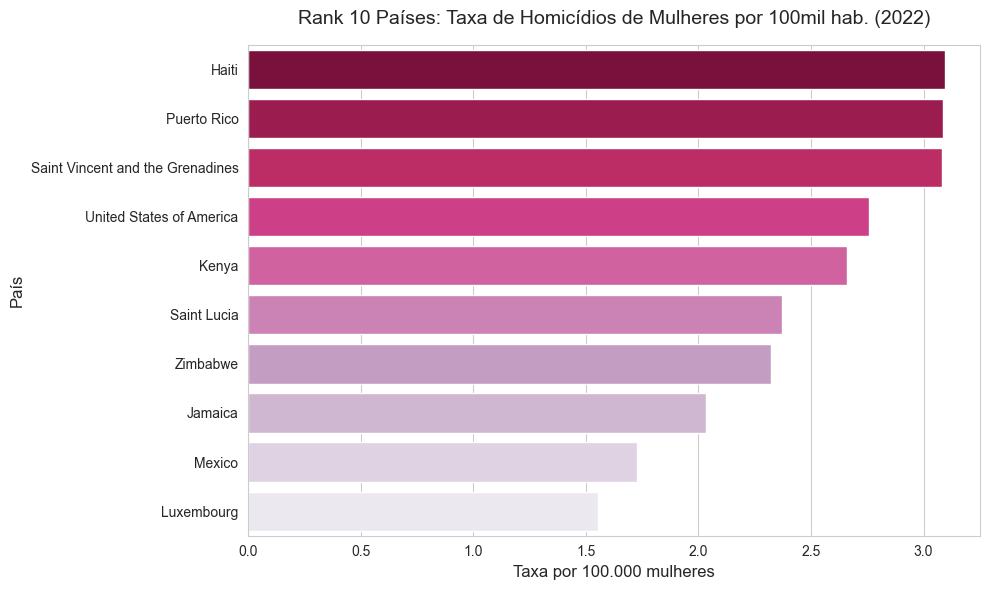

In [11]:
# Top 10 índices de homicídios de mulheres em 2022
# Pergunta 2 - Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022?

# Filtramos o ano de 2022 e o sexo Feminino
df_p2 = df[
    (df['Year'] == 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Female') &
    (df['Age'] == 'Total')
].copy()

#  Agrupar por país e calcular a média da taxa no ano
top_10_mulheres = df_p2.groupby('Country')['VALUE'].mean().sort_values(ascending=False).head(10).reset_index()

print(" Rank dos 10 paises com maiores taxas de homicidios em mulheres no ano de 2022 ")
display(top_10_mulheres)

# Análise Exploratória
plt.figure(figsize=(10, 6))
# Usando a paleta PuRd_r (Purple-Red invertida) para diferenciar do gráfico anterior
sns.barplot(data=top_10_mulheres, x='VALUE', y='Country', palette='PuRd_r')

plt.title('Rank 10 Países: Taxa de Homicídios de Mulheres por 100mil hab. (2022)', fontsize=14, pad=15)
plt.xlabel('Taxa por 100.000 mulheres', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

--- REGIÕES COM MAIORES TAXAS DE HOMICÍDIOS POR 100 MIL HAB. (MÉDIA 2018-2022) ---


,Region,VALUE
0,Americas,5.128231
1,Africa,2.019646
2,Oceania,1.246470
3,Asia,1.124368
4,Europe,0.444131


C:\Users\User\AppData\Local\Temp\ipykernel_11556\558515536.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_regioes, x='VALUE', y='Region', palette='magma')


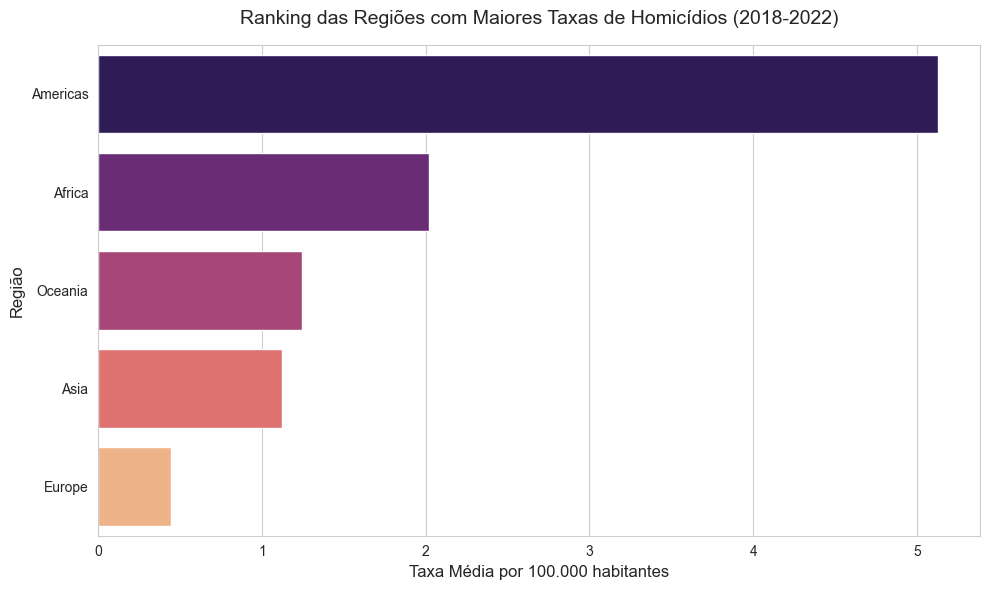

In [12]:
# Regiões com maiores taxas de homicídios (2018-2022)

# Pergunta 3 - Quais as regiões com mais homicídios nos últimos 5 anos?

#Filtramos somente o que vamos usar nessa questão
df_p3 = df[
    (df['Year'] >= 2018) &
    (df['Year'] <= 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

rank_regioes = df_p3.groupby('Region')['VALUE'].mean().sort_values(ascending=False).reset_index()

print("--- REGIÕES COM MAIORES TAXAS DE HOMICÍDIOS POR 100 MIL HAB. (MÉDIA 2018-2022) ---")
display(rank_regioes)

# Análise Exploratória
plt.figure(figsize=(10, 6))
sns.barplot(data=rank_regioes, x='VALUE', y='Region', palette='magma')

plt.title('Ranking das Regiões com Maiores Taxas de Homicídios (2018-2022)', fontsize=14, pad=15)
plt.xlabel('Taxa Média por 100.000 habitantes', fontsize=12)
plt.ylabel('Região', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# Pergunta 4 - Quais países com menor número (taxa) de homicídios em cada subregião?


#  Utilizamos os dados gerais (taxa por 100mil hab, ambos os sexos)
df_geral = df[
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

# Taxa média de cada país dentro da sua subregião
df_subregioes = df_geral.groupby(['Subregion', 'Country'])['VALUE'].mean().reset_index()

indices_menores = df_subregioes.groupby('Subregion')['VALUE'].idxmin()

#  Filtramoa e ordenamos por subregião
menores_por_subregiao = df_subregioes.loc[indices_menores].sort_values('Subregion').reset_index(drop=True)

print("Paises com menores taxas de homicidios por sub-região")
display(menores_por_subregiao)

Paises com menores taxas de homicidios por sub-região


,Subregion,Country,VALUE
0,Australia and New Zealand,Australia,0.522769
1,Central Asia,Uzbekistan,1.411846
2,Eastern Asia,Japan,0.239357
3,Eastern Europe,Czechia,0.350578
4,Latin America and the Caribbean,Bolivia (Plurinational State of),1.292424
5,Melanesia,Vanuatu,0.432898
6,Micronesia,Micronesia (Federated States of),0.448920
7,Northern Africa,Algeria,0.394146
8,Northern America,Canada,0.598476
9,Northern Europe,Iceland,0.190852


Rank dos 10 paises que tiveram menores taxas de homicidios de mulheres


,Country,VALUE
0,Madagascar,0.048450
1,Algeria,0.149495
2,Oman,0.160996
3,Morocco,0.178668
4,Singapore,0.215083
5,Bahrain,0.217197
6,Spain,0.235084
7,Italy,0.248980
8,State of Palestine,0.277345
9,Egypt,0.286670


C:\Users\User\AppData\Local\Temp\ipykernel_11556\3077604148.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=menores_mulheres, x='VALUE', y='Country', palette='Blues_r')


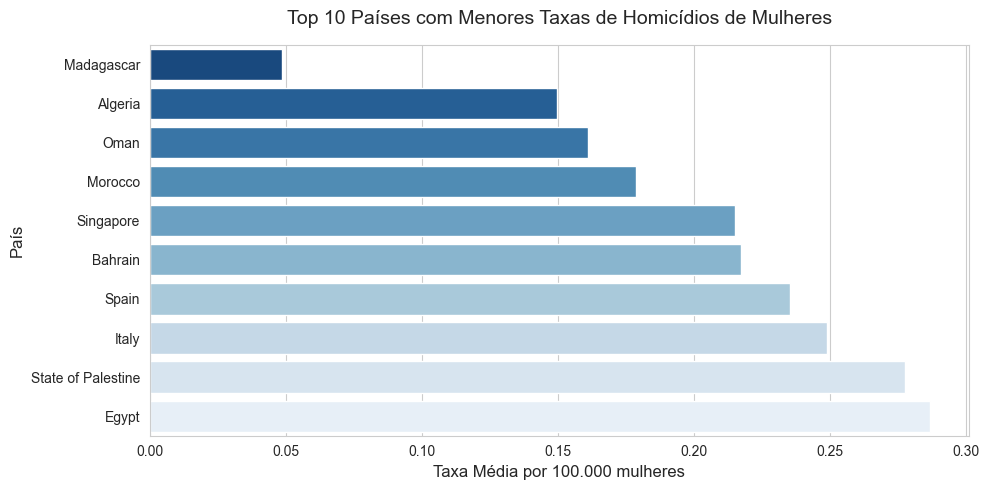

In [14]:
#  Pergunta 5 - Quais países com menor número de morte de mulheres?


# Filtramos o sexo feminino e a taxa
df_mulheres = df[
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Female') &
    (df['Age'] == 'Total')
].copy()

# Filtramos taxas maiores que 0 para evitar erros de base (países que não reportaram)
df_mulheres_valido = df_mulheres[df_mulheres['VALUE'] > 0]
menores_mulheres = df_mulheres_valido.groupby('Country')['VALUE'].mean().sort_values(ascending=True).head(10).reset_index()

print("Rank dos 10 paises que tiveram menores taxas de homicidios de mulheres")
display(menores_mulheres)

plt.figure(figsize=(10, 5))
sns.barplot(data=menores_mulheres, x='VALUE', y='Country', palette='Blues_r')

plt.title('Top 10 Países com Menores Taxas de Homicídios de Mulheres', fontsize=14, pad=15)
plt.xlabel('Taxa Média por 100.000 mulheres', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

Sub regiões com maiores taxas de homicídios


,Subregion,VALUE
0,Latin America and the Caribbean,8.135854
1,Sub-Saharan Africa,6.849622
2,Polynesia,4.698450
3,Melanesia,4.418365
4,Central Asia,3.410197
5,Micronesia,3.334466
6,South-eastern Asia,2.421428
7,Northern America,2.176800
8,Southern Asia,1.977959
9,Eastern Europe,1.771202


C:\Users\User\AppData\Local\Temp\ipykernel_11556\3339648780.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_subregioes.head(10), x='VALUE', y='Subregion', palette='Oranges_r')


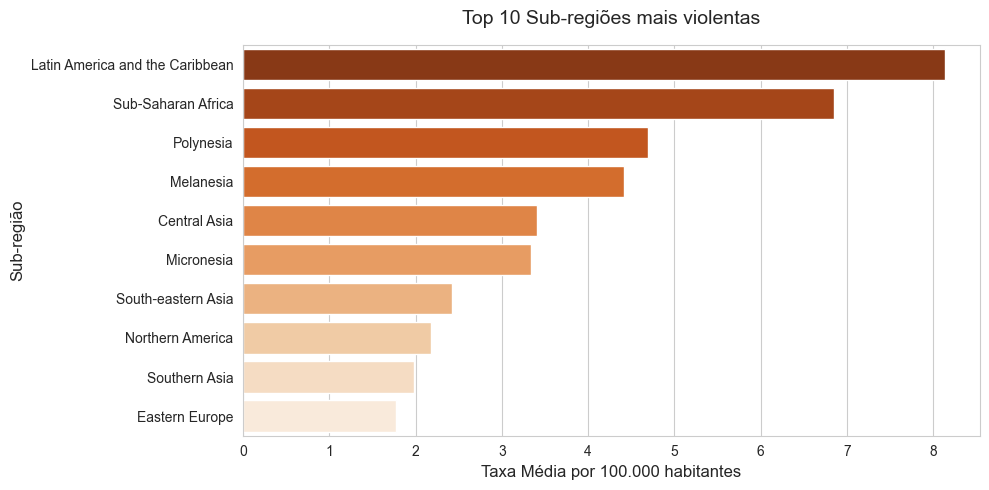

In [15]:
#  Pergunta 6 - Quais as sub-regiões com as maiores taxas de homicídios?


#  Puxar a base geral (taxa por 100mil hab, ambos os sexos)
df_geral = df[
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

# Calculamos a média e ordenamos do maior pro menor
ranking_subregioes = df_geral.groupby('Subregion')['VALUE'].mean().sort_values(ascending=False).reset_index()

print("Sub regiões com maiores taxas de homicídios")
display(ranking_subregioes.head(10)) # Mostrando o Top 10 para não poluir a tela

# Plotagem dos gráficos
plt.figure(figsize=(10, 5))
sns.barplot(data=ranking_subregioes.head(10), x='VALUE', y='Subregion', palette='Oranges_r')
plt.title('Top 10 Sub-regiões mais violentas', fontsize=14, pad=15)
plt.xlabel('Taxa Média por 100.000 habitantes', fontsize=12)
plt.ylabel('Sub-região', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Pergunta 7 - País com maior número (taxa) de homicídios em cada continente em 2020


# Filtramos somente o ano de 2020
df_2020 = df[
    (df['Year'] == 2020) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

# Maiores indices por Continente (Dataset Geral)
indices_maiores_2020 = df_2020.groupby('Region')['VALUE'].idxmax()

# (Apenas por região, pais e valor)
maiores_por_continente_2020 = df_2020.loc[indices_maiores_2020, ['Region', 'Country', 'VALUE']].sort_values('VALUE', ascending=False).reset_index(drop=True)

print("Pais mais violento de cada continente em 2020")
display(maiores_por_continente_2020)

Pais mais violento de cada continente em 2020


,Region,Country,VALUE
0,Asia,Iraq (Central Iraq),65.335683
1,Americas,Jamaica,47.262196
2,Africa,South Africa,33.964873
3,Europe,Russian Federation,7.345966
4,Oceania,Fiji,2.172916


In [17]:
#  Pergunta 8 - Qual o país mais violento para as mulheres em 2021?


# Taxa por 100 mil e sexo feminino (2021)
df_2021_mulheres = df[
    (df['Year'] == 2021) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Female') &
    (df['Age'] == 'Total')
].copy()

par_mais_violento_2021 = df_2021_mulheres.sort_values('VALUE', ascending=False).head(1).reset_index(drop=True)

print("O pais mais violento para mulheres em 2021")
display(par_mais_violento_2021[['Country', 'VALUE']])

O pais mais violento para mulheres em 2021


,Country,VALUE
0,Antigua and Barbuda,10.265149


In [18]:
# Pergunta 9 - Qual o país com maior valor absoluto de homicídios ?


# Filtramos por 'Counts' (valor absoluto) para capturar o volume total acumulado
df_absoluto = df[
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Counts') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

# Pegamos o valor máximo histórico por país para analisar quem lidera o volume global
top_volume_global = df_absoluto.groupby('Country')['VALUE'].sum().sort_values(ascending=False).head(1).reset_index()

print("Pais com maior acumulado de vitimas")
display(top_volume_global)

Pais com maior acumulado de vitimas


,Country,VALUE
0,Brazil,1.571335e+06


Analise dos indices no Brasil
A taxa média de homicídios no Brasil nos últimos 10 anos é de: 18.60 por 100 mil habitantes.


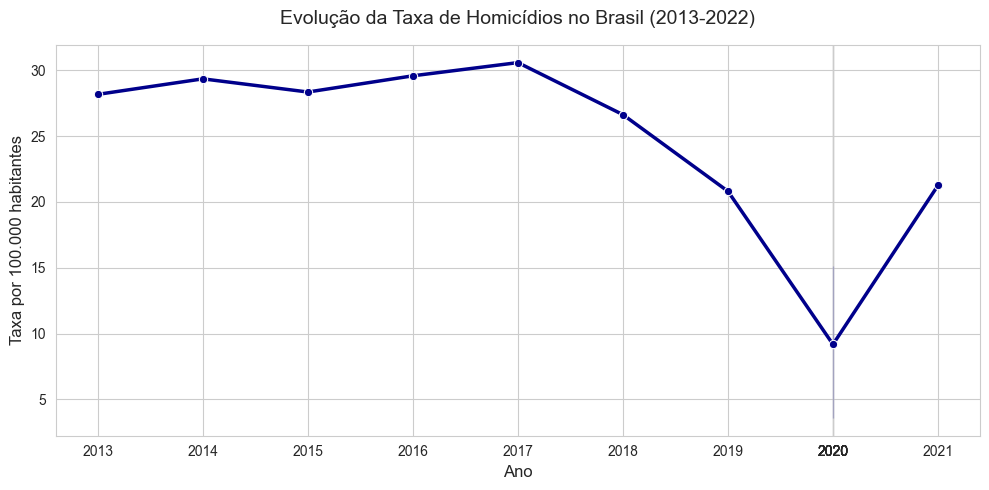

In [19]:
# Pergunta 10 - Média de homicídios (Taxa) no Brasil nos últimos 10 anos (2013-2022)


# Filtramos por dados somente do Brasil
df_brasil = df[
    (df['Country'] == 'Brazil') &
    (df['Year'] >= 2013) & (df['Year'] <= 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
].copy()

media_brasil = df_brasil['VALUE'].mean()

print(f"Analise dos indices no Brasil")
print(f"A taxa média de homicídios no Brasil nos últimos 10 anos é de: {media_brasil:.2f} por 100 mil habitantes.")

# Plotagem do grafico
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_brasil, x='Year', y='VALUE', marker='o', color='darkblue', linewidth=2.5)
plt.title('Evolução da Taxa de Homicídios no Brasil (2013-2022)', fontsize=14, pad=15)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Taxa por 100.000 habitantes', fontsize=12)
plt.xticks(df_brasil['Year'])
plt.tight_layout()
plt.show()

In [20]:
# Exportamos o dataset enxuto para ser usado na regressão
df_unodc_filtrado = df[
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['VALUE'] > 0)
].copy()

df_unodc_filtrado.to_excel("dados_processados.xlsx", index=False)
print("Base de dados 'dados_processados.xlsx' gerada com sucesso!")

Base de dados 'dados_processados.xlsx' gerada com sucesso!
